# Fairness & Causal-Robustness Benchmark — Graph & Data Regeneration

This notebook regenerates **every table and chart** used in the HTML results report and slide deck, from the five models' raw result CSVs:

`CFFair`, `CLAIRE`, `SRCVAE`, `XGBoost`, `FairPFN` — each with a **Synthetic (SF)** and **Semi-Synthetic (HR)** results file.

**How to use it:** put this notebook in the same folder as your 10 CSVs (or edit `DATA_DIR` below), then **Run All**. Every chart is saved to `outputs/charts/` and every computed table to `outputs/tables/`, and everything also renders inline below. Re-run any time you refresh the underlying CSVs — nothing here is hand-typed, so tables/charts/narratives you build on top of this will always reflect the latest data.

**Sections**
1. Setup & configuration
2. Load & parse the 10 result files
3. Composite metric — Distance to Optimal Fair Solution (DOFS)
4. Data coverage summary (which models were tested on which configurations)
5. Synthetic (SF) data — individual & combined charts
6. Semi-Synthetic (HR) data — individual & combined charts
7. Cross-model ranking & rank correlation
8. Sensitivity analysis (permutation importance, EBM-style)
9. Final cross-regime comparison

## 1. Setup & configuration

In [1]:
import os, re, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', None)
plt.rcParams.update({'font.size': 10, 'figure.dpi': 120})

# ---- EDIT THESE IF YOUR FOLDER LAYOUT DIFFERS ----
DATA_DIR = "."                      # folder containing the 10 CSVs (default: same folder as this notebook)
OUTPUT_DIR = "outputs"              # where charts/tables get written
CHARTS_DIR = os.path.join(OUTPUT_DIR, "charts")
TABLES_DIR = os.path.join(OUTPUT_DIR, "tables")
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

SYN_FILES = {
    "CFFair":  "CFFair_syn_results.csv",
    "CLAIRE":  "CLAIRE_syn_results.csv",
    "SRCVAE":  "SRCVAE_syn_results.csv",
    "XGBoost": "xgb_syn_results.csv",
    "FairPFN": "fairpfn_results.csv",
}
SEMI_FILES = {
    "CFFair":  "CFFair_semi_syn_results.csv",
    "CLAIRE":  "CLAIRE_semi_syn_results.csv",
    "SRCVAE":  "SRCVAE_semi_syn_results.csv",
    "XGBoost": "xgb_semi_syn_results.csv",
    "FairPFN": "fairpfn_semi_syn_results.csv",
}

MODELS = ["CFFair", "CLAIRE", "SRCVAE", "XGBoost", "FairPFN"]
COLORS = {"CFFair": "#2563eb", "CLAIRE": "#dc2626", "SRCVAE": "#16a34a", "XGBoost": "#ca8a04", "FairPFN": "#9333ea"}
BIAS_ORDER = ["LowBias", "MedBias", "HighBias", "PolicyDom", "WealthDom"]
print('Config OK. Looking for CSVs in:', os.path.abspath(DATA_DIR))

Config OK. Looking for CSVs in: c:\Users\patri\Documents\Master Semesters\2nd semester\APA\model_testing


## 2. Load & parse the 10 result files

Synthetic (SF) filenames encode generative metadata (`base_nodes`, `u_frac`, `seed`, sample-size label) that isn't in its own column — this parses it out. Semi-synthetic (HR) files already have `bias_level`, `data_type`, `threshold`, `n_U` as columns; only the seed needs to be parsed from `name_dataset`.

In [2]:
def parse_syn_name(name):
    d = {}
    d['sample_size_label'] = 'Large' if 'Large' in name else ('Small' if 'Small' in name else None)
    m2 = re.search(r'(\d+)_base_nodes', name)
    d['base_nodes'] = int(m2.group(1)) if m2 else None
    m3 = re.search(r'u_(\d+)p(\d+)', name)
    d['u_frac'] = float(f"{m3.group(1)}.{m3.group(2)}") if m3 else None
    m4 = re.search(r'seed_(\d+)', name)
    d['seed'] = int(m4.group(1)) if m4 else None
    m5 = re.search(r'(\d+)_nodes_full_data', name)
    d['total_nodes'] = int(m5.group(1)) if m5 else None
    d['nonlinear_pattern'] = 'Linear_ReLU_50%' if 'Linear_ReLU_50%' in name else ('Linear_100%' if 'Linear' in name and 'ReLU' not in name else name)
    return d

def parse_semi_seed(name):
    m = re.search(r'Seed(\d+)', name)
    return int(m.group(1)) if m else None

def load_all():
    dfs_syn = []
    for model, fname in SYN_FILES.items():
        path = os.path.join(DATA_DIR, fname)
        df = pd.read_csv(path)
        df['model_name'] = model
        meta = df['name_dataset'].apply(parse_syn_name).apply(pd.Series)
        df = pd.concat([df, meta], axis=1)
        df['regime'] = 'Synthetic (SF)'
        dfs_syn.append(df)
    syn_all = pd.concat(dfs_syn, ignore_index=True)

    dfs_semi = []
    for model, fname in SEMI_FILES.items():
        path = os.path.join(DATA_DIR, fname)
        df = pd.read_csv(path)
        df['model_name'] = model
        df['seed'] = df['name_dataset'].apply(parse_semi_seed)
        df['regime'] = 'Semi-Synthetic (HR)'
        dfs_semi.append(df)
    semi_all = pd.concat(dfs_semi, ignore_index=True)
    return syn_all, semi_all

syn_all, semi_all = load_all()
print('Synthetic (SF):', syn_all.shape)
print(syn_all.groupby('model_name').size())
print()
print('Semi-Synthetic (HR):', semi_all.shape)
print(semi_all.groupby('model_name').size())

Synthetic (SF): (236, 23)
model_name
CFFair     60
CLAIRE     80
FairPFN     8
SRCVAE     80
XGBoost     8
dtype: int64

Semi-Synthetic (HR): (3000, 21)
model_name
CFFair     400
CLAIRE     600
FairPFN    600
SRCVAE     800
XGBoost    600
dtype: int64


## 3. Composite metric — Distance to Optimal Fair Solution (DOFS)

A TOPSIS-style aggregation of 8 metrics (5 predictive + 3 fairness), following Velev & Lessmann's Algorithm 1:
- **Maximize** (best=1, worst=0): `ROC_AUC`, `Accuracy`, `Precision`, `Recall`, `F1_Score`
- **Minimize** (best=0, worst=1): `Statistical_Parity_Diff_(ATE)`, `Equal_Opportunity_Diff`, and `DIR_dist` — a symmetrized, bounded transform of the Disparate Impact Ratio (`DIR_dist = 1 - min(DIR, 1/DIR)`), which safely handles the ~10% of runs where raw DIR is undefined (a group's predicted positive rate hits exactly zero).

`DOFS = dist_to_worst / (dist_to_worst + dist_to_best)`, reported as **predictive-only**, **fairness-only**, and **combined** variants.

In [3]:
def add_dofs(df):
    df = df.copy()
    dir_ = df['Disparate_Impact_Ratio'].replace([np.inf, -np.inf], np.nan)
    sym = np.minimum(dir_, 1 / dir_.replace(0, np.nan))
    sym = sym.fillna(0)  # inf or 0 DIR -> maximal disparity -> sym=0
    df['DIR_dist'] = 1 - sym

    maximize_cols = ['ROC_AUC', 'Accuracy', 'Precision', 'Recall', 'F1_Score']
    minimize_cols = ['Statistical_Parity_Diff_(ATE)', 'Equal_Opportunity_Diff', 'DIR_dist']
    for c in minimize_cols:
        df[c + '_clip'] = df[c].clip(0, 1)

    best_components, worst_components = [], []
    for c in maximize_cols:
        best_components.append((1 - df[c]) ** 2)
        worst_components.append((0 - df[c]) ** 2)
    for c in minimize_cols:
        v = df[c + '_clip']
        best_components.append((0 - v) ** 2)
        worst_components.append((1 - v) ** 2)
    dist_best = np.sqrt(sum(best_components))
    dist_worst = np.sqrt(sum(worst_components))
    df['DOFS'] = dist_worst / (dist_worst + dist_best)

    pbest = np.sqrt(sum((1 - df[c]) ** 2 for c in maximize_cols))
    pworst = np.sqrt(sum((0 - df[c]) ** 2 for c in maximize_cols))
    df['DOFS_predictive'] = pworst / (pworst + pbest)

    fbest = np.sqrt(sum((0 - df[c + '_clip']) ** 2 for c in minimize_cols))
    fworst = np.sqrt(sum((1 - df[c + '_clip']) ** 2 for c in minimize_cols))
    df['DOFS_fairness'] = fworst / (fworst + fbest)
    return df

syn_all = add_dofs(syn_all)
semi_all = add_dofs(semi_all)

syn_all.to_csv(os.path.join(TABLES_DIR, 'synthetic_SF_with_DOFS.csv'), index=False)
semi_all.to_csv(os.path.join(TABLES_DIR, 'semi_synthetic_HR_with_DOFS.csv'), index=False)

print('DOFS added. Mean DOFS by model:')
print(syn_all.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().round(3))
print()
print(semi_all.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().round(3))

DOFS added. Mean DOFS by model:
             DOFS  DOFS_predictive  DOFS_fairness
model_name                                       
CFFair      0.785            0.910          0.676
CLAIRE      0.766            0.865          0.681
FairPFN     0.794            0.751          0.921
SRCVAE      0.682            0.637          0.775
XGBoost     0.735            0.800          0.690

             DOFS  DOFS_predictive  DOFS_fairness
model_name                                       
CFFair      0.829            0.814          0.890
CLAIRE      0.764            0.746          0.831
FairPFN     0.776            0.747          0.862
SRCVAE      0.689            0.607          0.847
XGBoost     0.753            0.751          0.796


## 4. Data coverage summary

Model test coverage is **not** identical across models — this must be checked every time the CSVs are refreshed, since any cross-model ranking should only compare configurations every model was actually tested on.

In [4]:
cov_syn = syn_all.groupby(['model_name', 'base_nodes', 'u_frac'])['seed'].nunique().unstack(['base_nodes', 'u_frac']).reindex(MODELS)
print('Synthetic (SF): seeds available per model x (base_nodes, u_frac)')
display(cov_syn)
cov_syn.to_csv(os.path.join(TABLES_DIR, 'coverage_synthetic.csv'))

cov_semi = semi_all.groupby(['model_name', 'data_type']).size().unstack().reindex(MODELS)
print()
print('Semi-Synthetic (HR): test-run count per model x data_type')
display(cov_semi)
cov_semi.to_csv(os.path.join(TABLES_DIR, 'coverage_semi_synthetic.csv'))

cov_nU = semi_all.groupby(['model_name', 'n_U']).size().unstack()
print()
print('Semi-Synthetic (HR): test-run count per model x n_U')
display(cov_nU)

Synthetic (SF): seeds available per model x (base_nodes, u_frac)


base_nodes    10                20                10    20
u_frac       0.5   1.0   2.0   0.5   1.0   2.0   0.0   0.0
model_name                                                
CFFair      10.0  10.0  10.0  10.0  10.0  10.0   NaN   NaN
CLAIRE      10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
SRCVAE      10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0
XGBoost      1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0
FairPFN      1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0


Semi-Synthetic (HR): test-run count per model x data_type


data_type,BIASED_ALL,BIASED_FAIRNESS,BIASED_MASKED,FAIR_ALL
model_name,,,,
CFFair,200.0,NaN,NaN,200.0
CLAIRE,200.0,200.0,NaN,200.0
SRCVAE,200.0,200.0,200.0,200.0
XGBoost,200.0,200.0,NaN,200.0
FairPFN,200.0,200.0,NaN,200.0



Semi-Synthetic (HR): test-run count per model x n_U


n_U,0,4
model_name,,
CFFair,NaN,400.0
CLAIRE,200.0,400.0
FairPFN,200.0,400.0
SRCVAE,400.0,400.0
XGBoost,200.0,400.0


## 4b. Core (fair-comparison) subsets

To keep any cross-model ranking honest given the coverage gaps above, every cross-model comparison below uses only the configurations **every** model was actually tested on:
- **Synthetic core**: `u_frac ∈ {0.5, 1.0, 2.0}` (drops the `u_frac=0.0` no-confounding baseline, which CFFair never ran)
- **Semi-synthetic core**: `data_type ∈ {BIASED_ALL, FAIR_ALL}` and `n_U = 4` (the only combination shared by all 5 models)

In [5]:
syn_core = syn_all[syn_all['u_frac'].isin([0.5, 1.0, 2.0])].copy()
semi_core = semi_all[(semi_all['data_type'].isin(['BIASED_ALL', 'FAIR_ALL'])) & (semi_all['n_U'] == 4)].copy()

syn_core.to_csv(os.path.join(TABLES_DIR, 'synthetic_core_subset.csv'), index=False)
semi_core.to_csv(os.path.join(TABLES_DIR, 'semi_synthetic_core_subset.csv'), index=False)

print('Synthetic core subset — rows per model:')
print(syn_core.groupby('model_name').size())
print()
print('Semi-synthetic core subset — rows per model:')
print(semi_core.groupby('model_name').size())

Synthetic core subset — rows per model:
model_name
CFFair     60
CLAIRE     60
FairPFN     6
SRCVAE     60
XGBoost     6
dtype: int64

Semi-synthetic core subset — rows per model:
model_name
CFFair     400
CLAIRE     400
FairPFN    400
SRCVAE     400
XGBoost    400
dtype: int64


## 5. Synthetic (SF) data — charts

### 5.1 Coverage heatmap

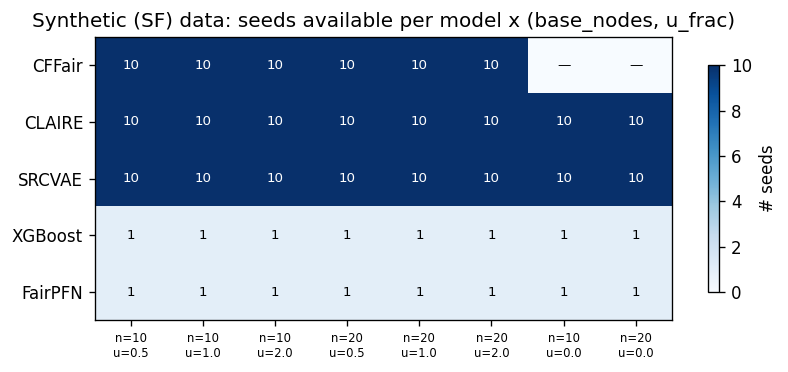

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
cov = syn_all.groupby(['model_name', 'base_nodes', 'u_frac'])['seed'].nunique().unstack(['base_nodes', 'u_frac']).reindex(MODELS)
im = ax.imshow(cov.fillna(0), cmap='Blues', vmin=0, vmax=10, aspect='auto')
ax.set_yticks(range(len(cov.index))); ax.set_yticklabels(cov.index)
ax.set_xticks(range(len(cov.columns)))
ax.set_xticklabels([f"n={b}\nu={u}" for b, u in cov.columns], fontsize=7)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.iloc[i, j]
        txt = '—' if pd.isna(v) else int(v)
        ax.text(j, i, txt, ha='center', va='center', fontsize=8, color='black' if pd.isna(v) or v < 6 else 'white')
ax.set_title('Synthetic (SF) data: seeds available per model x (base_nodes, u_frac)')
plt.colorbar(im, label='# seeds', shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, 'syn_coverage.png'))
plt.show()

### 5.2 Predictive performance vs. confounding ratio — per model (small multiples)

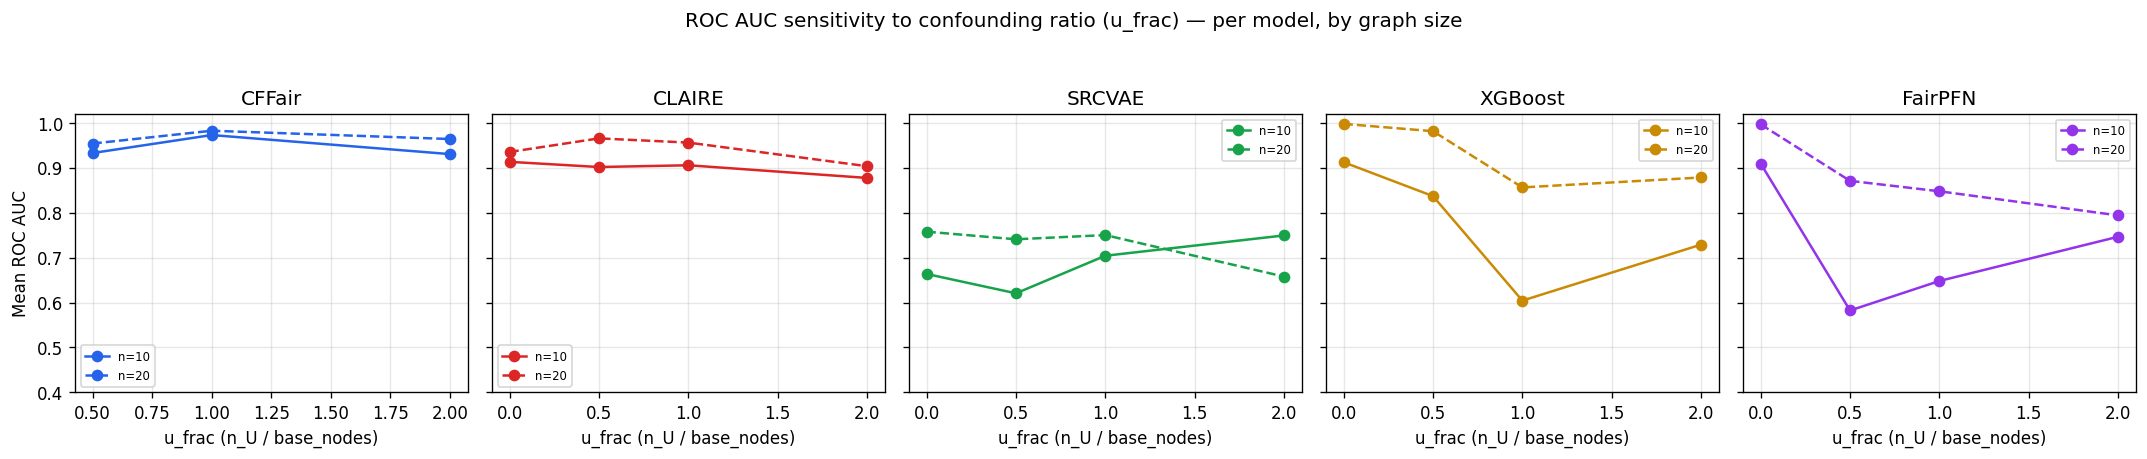

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = syn_all[syn_all.model_name == model]
    for bn, ls in zip([10, 20], ['-', '--']):
        s2 = sub[sub.base_nodes == bn].groupby('u_frac')['ROC_AUC'].mean()
        if len(s2):
            ax.plot(s2.index, s2.values, marker='o', linestyle=ls, color=COLORS[model], label=f'n={bn}')
    ax.set_title(model); ax.set_xlabel('u_frac (n_U / base_nodes)')
    ax.set_ylim(0.4, 1.02); ax.grid(alpha=0.3); ax.legend(fontsize=7)
axes[0].set_ylabel('Mean ROC AUC')
plt.suptitle('ROC AUC sensitivity to confounding ratio (u_frac) — per model, by graph size', y=1.05)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_rocauc_smallmultiple.png'), bbox_inches='tight')
plt.show()

### 5.3 Fairness gap vs. confounding ratio — per model (small multiples)

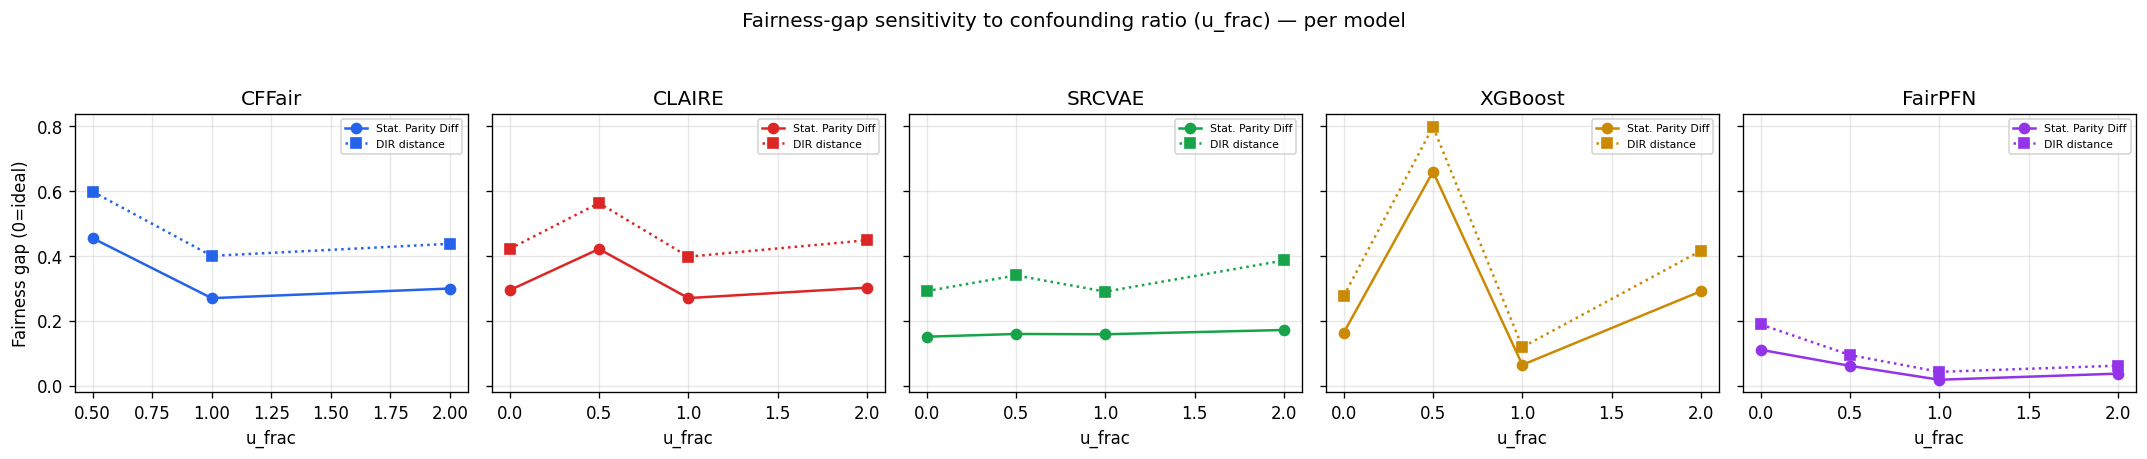

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = syn_all[syn_all.model_name == model]
    s2 = sub.groupby('u_frac')['Statistical_Parity_Diff_(ATE)'].mean()
    s3 = sub.groupby('u_frac')['DIR_dist'].mean()
    ax.plot(s2.index, s2.values, marker='o', color=COLORS[model], label='Stat. Parity Diff')
    ax.plot(s3.index, s3.values, marker='s', color=COLORS[model], linestyle=':', label='DIR distance')
    ax.set_title(model); ax.set_xlabel('u_frac')
    ax.grid(alpha=0.3); ax.legend(fontsize=6.5)
axes[0].set_ylabel('Fairness gap (0=ideal)')
plt.suptitle('Fairness-gap sensitivity to confounding ratio (u_frac) — per model', y=1.05)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_fairness_smallmultiple.png'), bbox_inches='tight')
plt.show()

### 5.4 Combined overlays — all models together

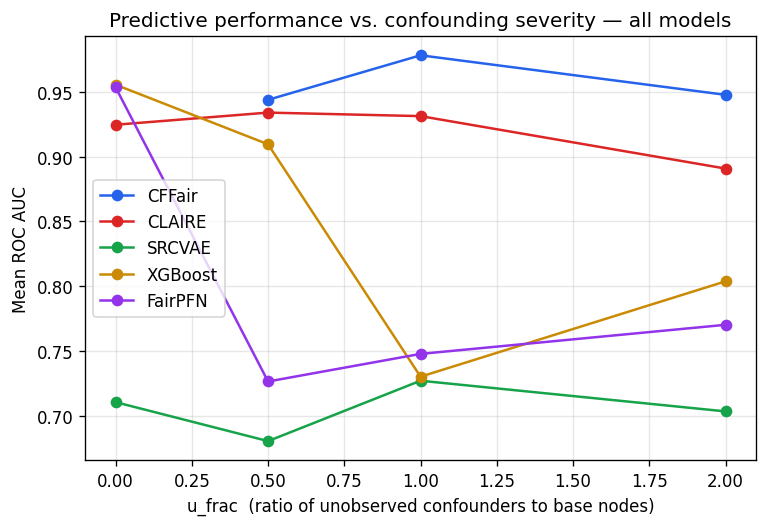

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for model in MODELS:
    sub = syn_all[syn_all.model_name == model].groupby('u_frac')['ROC_AUC'].mean()
    ax.plot(sub.index, sub.values, marker='o', color=COLORS[model], label=model)
ax.set_xlabel('u_frac  (ratio of unobserved confounders to base nodes)')
ax.set_ylabel('Mean ROC AUC')
ax.set_title('Predictive performance vs. confounding severity — all models')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_rocauc_overlay.png'))
plt.show()

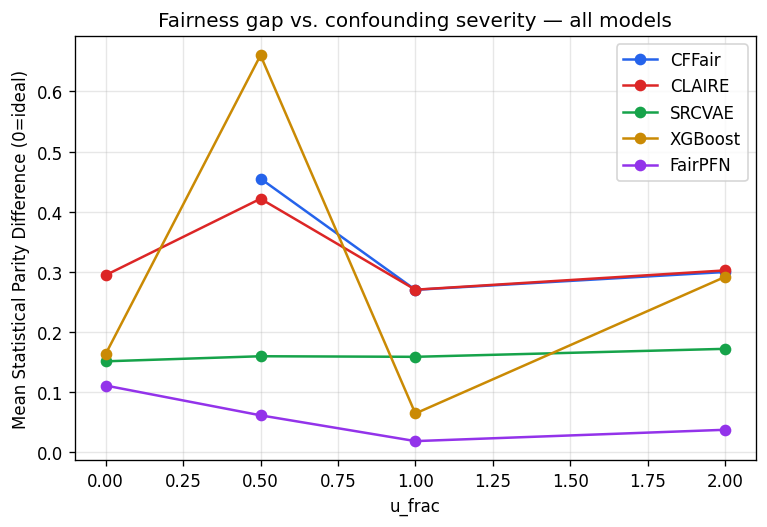

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for model in MODELS:
    sub = syn_all[syn_all.model_name == model].groupby('u_frac')['Statistical_Parity_Diff_(ATE)'].mean()
    ax.plot(sub.index, sub.values, marker='o', color=COLORS[model], label=model)
ax.set_xlabel('u_frac')
ax.set_ylabel('Mean Statistical Parity Difference (0=ideal)')
ax.set_title('Fairness gap vs. confounding severity — all models')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_spd_overlay.png'))
plt.show()

### 5.5 Fairness–Accuracy Frontier

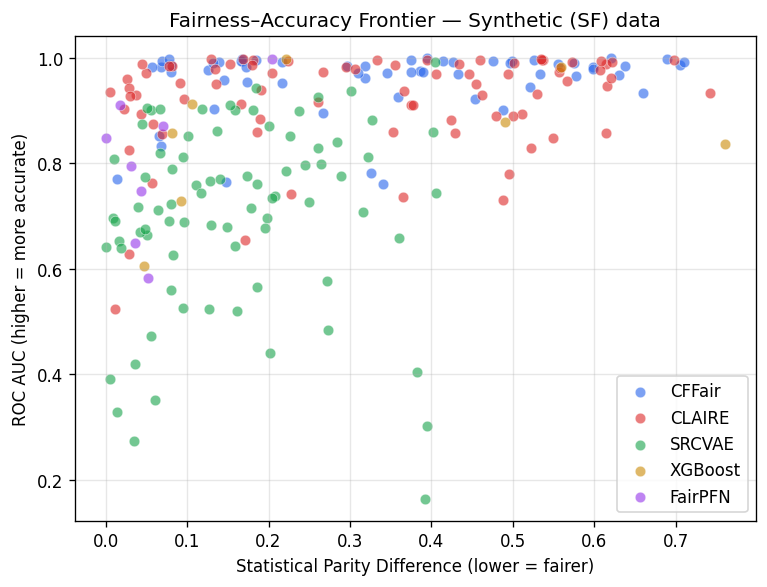

In [11]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for model in MODELS:
    sub = syn_all[syn_all.model_name == model]
    ax.scatter(sub['Statistical_Parity_Diff_(ATE)'], sub['ROC_AUC'], s=40, alpha=0.6,
               color=COLORS[model], label=model, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Statistical Parity Difference (lower = fairer)')
ax.set_ylabel('ROC AUC (higher = more accurate)')
ax.set_title('Fairness–Accuracy Frontier — Synthetic (SF) data')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_frontier.png'))
plt.show()

### 5.6 Composite DOFS by model (core subset)

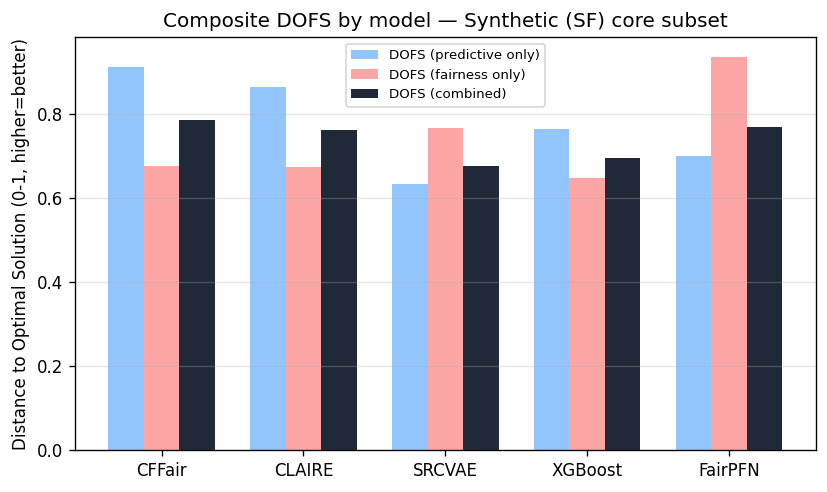

,DOFS,DOFS_predictive,DOFS_fairness
model_name,,,
CFFair,0.785,0.910,0.676
CLAIRE,0.761,0.864,0.674
SRCVAE,0.676,0.633,0.766
XGBoost,0.695,0.763,0.646
FairPFN,0.768,0.699,0.936


In [12]:
means = syn_core.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().reindex(MODELS)
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(MODELS)); w = 0.25
ax.bar(x - w, means['DOFS_predictive'], width=w, label='DOFS (predictive only)', color='#93c5fd')
ax.bar(x, means['DOFS_fairness'], width=w, label='DOFS (fairness only)', color='#fca5a5')
ax.bar(x + w, means['DOFS'], width=w, label='DOFS (combined)', color='#1f2937')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel('Distance to Optimal Solution (0-1, higher=better)')
ax.set_title('Composite DOFS by model — Synthetic (SF) core subset')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_dofs_bar.png'))
plt.show()
display(means.round(3))

## 6. Semi-Synthetic (HR) data — charts

### 6.1 Coverage heatmap

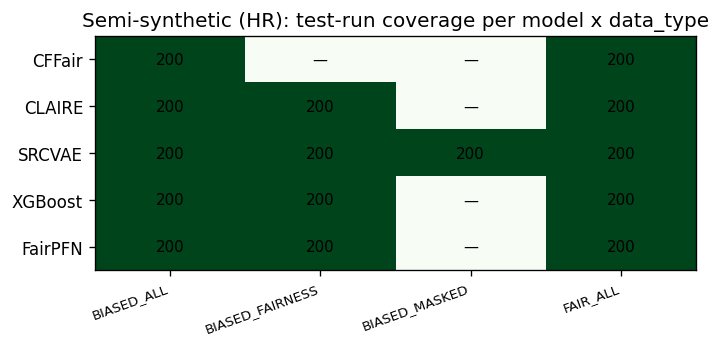

In [13]:
fig, ax = plt.subplots(figsize=(6, 3))
cov = semi_all.groupby(['model_name', 'data_type']).size().unstack().reindex(MODELS)
dtypes = ['BIASED_ALL', 'BIASED_FAIRNESS', 'BIASED_MASKED', 'FAIR_ALL']
cov = cov.reindex(columns=dtypes)
im = ax.imshow(cov.fillna(0), cmap='Greens', aspect='auto')
ax.set_yticks(range(len(cov.index))); ax.set_yticklabels(cov.index)
ax.set_xticks(range(len(cov.columns))); ax.set_xticklabels(cov.columns, rotation=20, ha='right', fontsize=8)
for i in range(cov.shape[0]):
    for j in range(cov.shape[1]):
        v = cov.iloc[i, j]
        txt = '—' if pd.isna(v) else int(v)
        ax.text(j, i, txt, ha='center', va='center', fontsize=9)
ax.set_title('Semi-synthetic (HR): test-run coverage per model x data_type')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_coverage.png'))
plt.show()

### 6.2 Predictive performance by bias scenario & ground-truth label

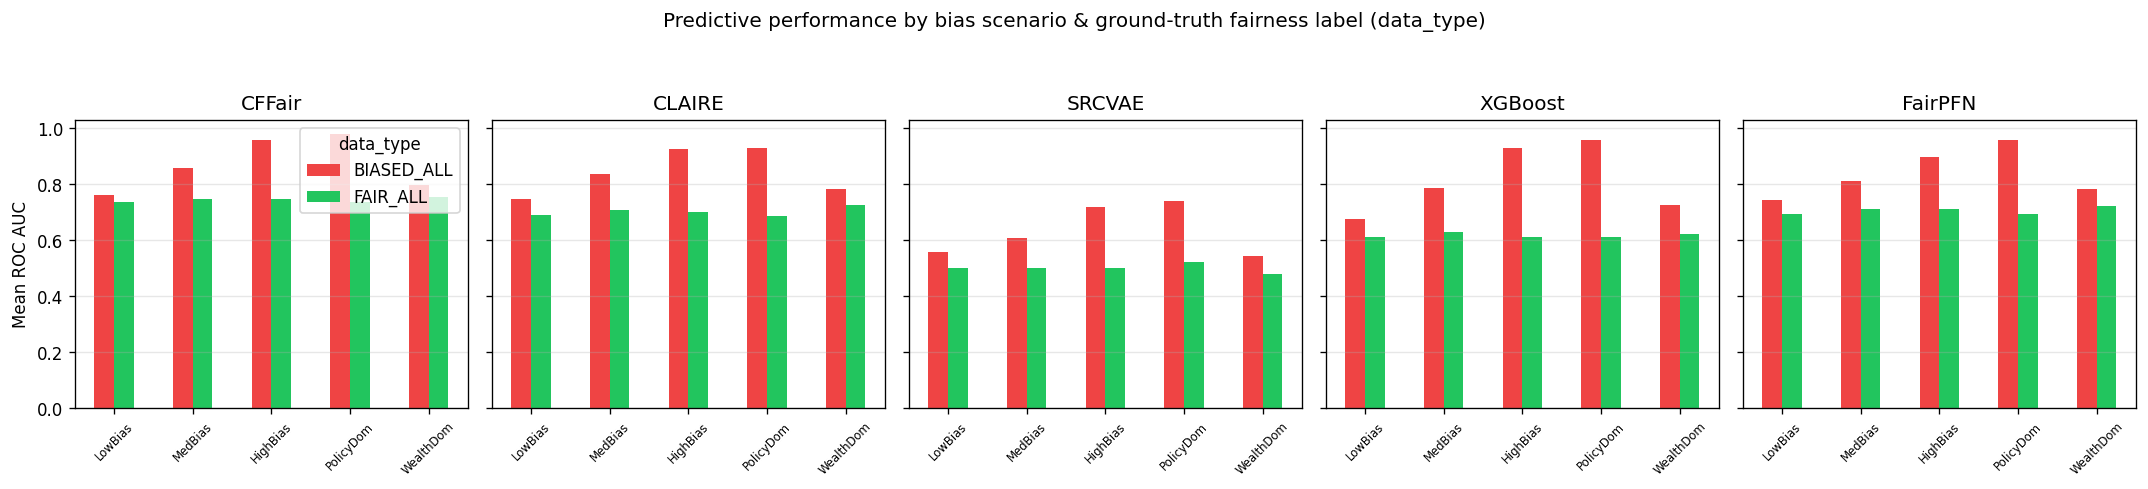

In [14]:
core_dtypes = ['BIASED_ALL', 'FAIR_ALL']
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = semi_all[(semi_all.model_name == model) & (semi_all.data_type.isin(core_dtypes))]
    piv = sub.groupby(['bias_level', 'data_type'])['ROC_AUC'].mean().unstack().reindex(BIAS_ORDER)
    piv.plot(kind='bar', ax=ax, color=['#ef4444', '#22c55e'], legend=(model == 'CFFair'))
    ax.set_title(model); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('Mean ROC AUC')
plt.suptitle('Predictive performance by bias scenario & ground-truth fairness label (data_type)', y=1.06)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_rocauc_smallmultiple.png'), bbox_inches='tight')
plt.show()

### 6.3 Bias-detection sanity check — SPD by data_type

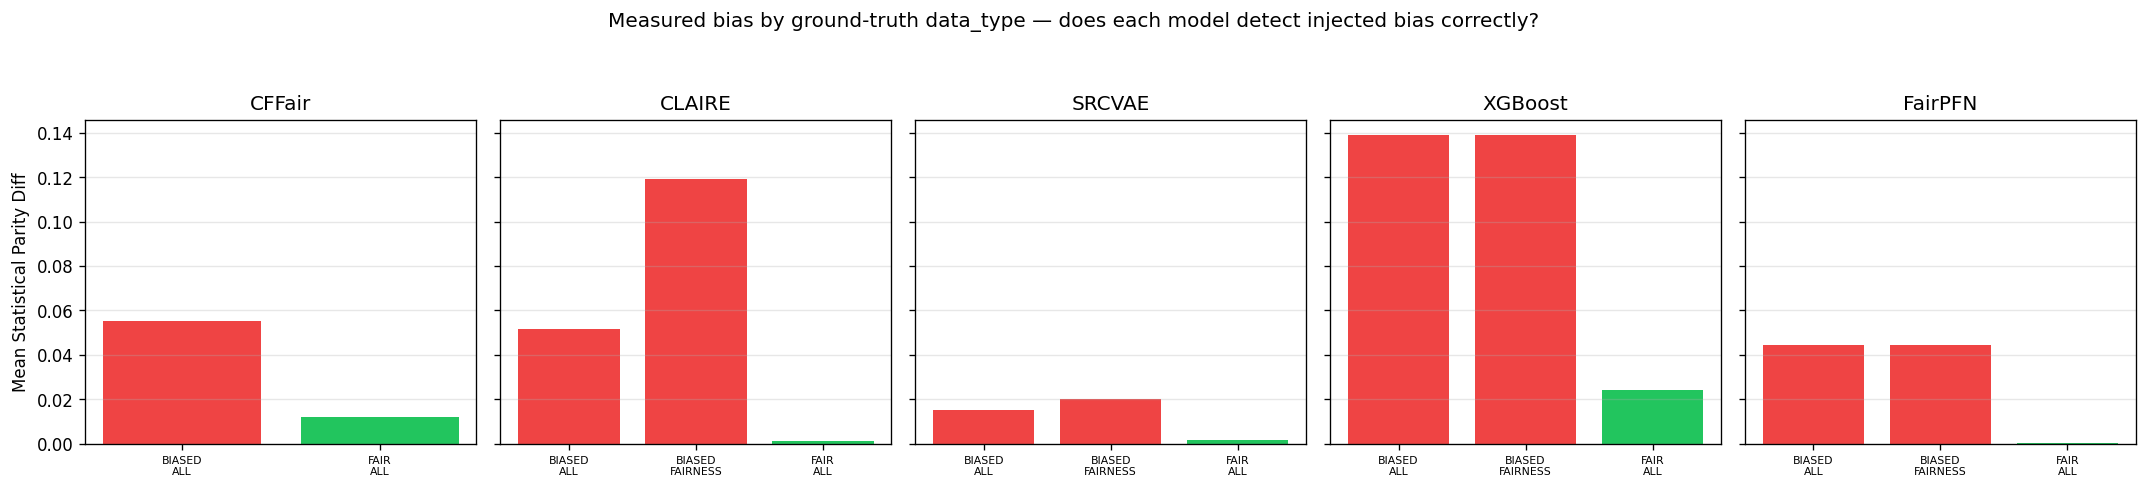

Bias-detection gap (BIASED_ALL minus FAIR_ALL, mean SPD):


data_type,BIASED_ALL,FAIR_ALL,detection_gap
model_name,,,
XGBoost,0.1388,0.0241,0.1147
CLAIRE,0.0517,0.0014,0.0502
FairPFN,0.0443,0.0003,0.0440
CFFair,0.0554,0.0119,0.0435
SRCVAE,0.0152,0.0016,0.0136


In [15]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = semi_all[semi_all.model_name == model]
    piv = sub.groupby('data_type')['Statistical_Parity_Diff_(ATE)'].mean().reindex(dtypes)
    piv = piv.dropna()
    colors_bar = ['#ef4444' if 'BIASED' in d else '#22c55e' for d in piv.index]
    ax.bar(range(len(piv)), piv.values, color=colors_bar)
    ax.set_xticks(range(len(piv))); ax.set_xticklabels([d.replace('_', '\n') for d in piv.index], fontsize=6.5)
    ax.set_title(model); ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('Mean Statistical Parity Diff')
plt.suptitle('Measured bias by ground-truth data_type — does each model detect injected bias correctly?', y=1.06)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_spd_by_datatype.png'), bbox_inches='tight')
plt.show()

print('Bias-detection gap (BIASED_ALL minus FAIR_ALL, mean SPD):')
gap = semi_all.groupby(['model_name', 'data_type'])['Statistical_Parity_Diff_(ATE)'].mean().unstack()[['BIASED_ALL', 'FAIR_ALL']]
gap['detection_gap'] = gap['BIASED_ALL'] - gap['FAIR_ALL']
display(gap.round(4).sort_values('detection_gap', ascending=False))

### 6.4 Effect of hiring threshold

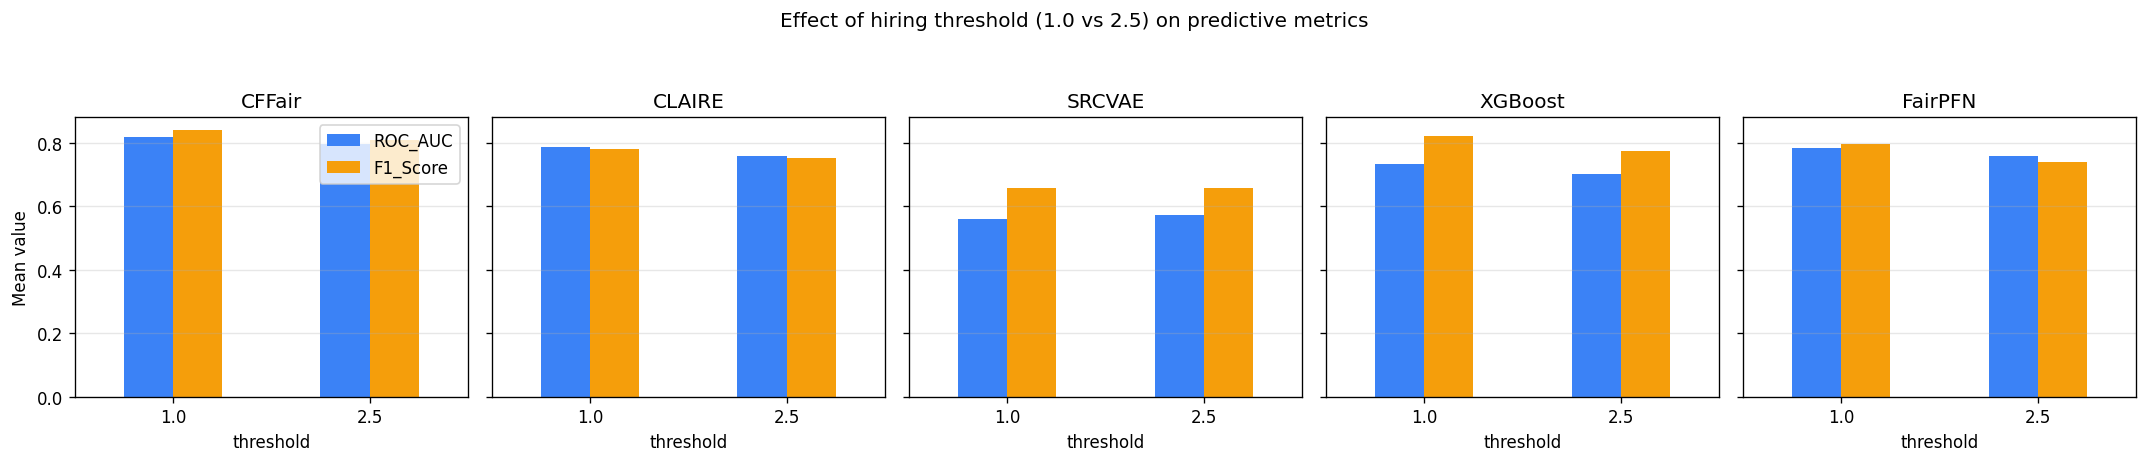

In [16]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, model in zip(axes, MODELS):
    sub = semi_all[(semi_all.model_name == model) & (semi_all.data_type.isin(core_dtypes))]
    piv = sub.groupby('threshold')[['ROC_AUC', 'F1_Score']].mean()
    piv.plot(kind='bar', ax=ax, color=['#3b82f6', '#f59e0b'], legend=(model == 'CFFair'))
    ax.set_title(model); ax.tick_params(axis='x', rotation=0)
    ax.grid(alpha=0.3, axis='y')
axes[0].set_ylabel('Mean value')
plt.suptitle('Effect of hiring threshold (1.0 vs 2.5) on predictive metrics', y=1.06)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_threshold_effect.png'), bbox_inches='tight')
plt.show()

### 6.5 Fairness gap across bias scenarios — combined overlay

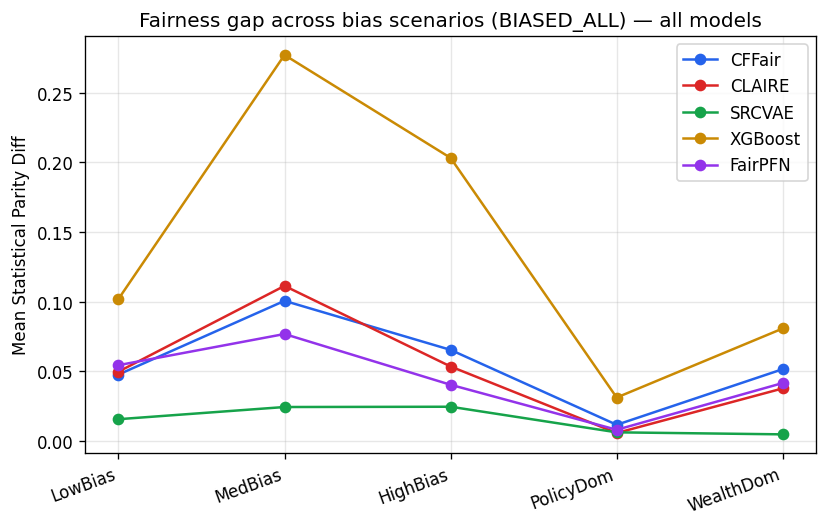

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for model in MODELS:
    sub = semi_all[(semi_all.model_name == model) & (semi_all.data_type == 'BIASED_ALL')]
    s = sub.groupby('bias_level')['Statistical_Parity_Diff_(ATE)'].mean().reindex(BIAS_ORDER)
    ax.plot(range(len(s)), s.values, marker='o', color=COLORS[model], label=model)
ax.set_xticks(range(len(BIAS_ORDER))); ax.set_xticklabels(BIAS_ORDER, rotation=20, ha='right')
ax.set_ylabel('Mean Statistical Parity Diff'); ax.set_title('Fairness gap across bias scenarios (BIASED_ALL) — all models')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_spd_overlay.png'))
plt.show()

### 6.6 Fairness–Accuracy Frontier (HR data)

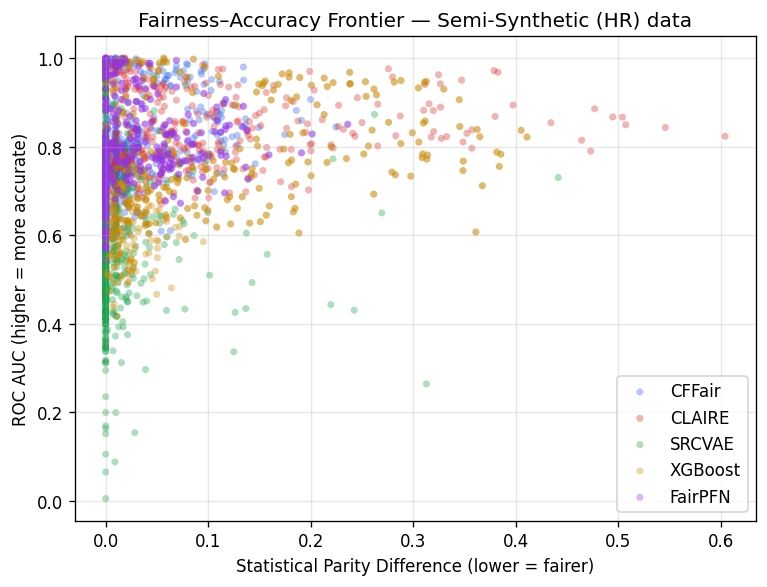

In [18]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for model in MODELS:
    sub = semi_all[semi_all.model_name == model]
    ax.scatter(sub['Statistical_Parity_Diff_(ATE)'], sub['ROC_AUC'], s=18, alpha=0.35,
               color=COLORS[model], label=model, edgecolor='none')
ax.set_xlabel('Statistical Parity Difference (lower = fairer)')
ax.set_ylabel('ROC AUC (higher = more accurate)')
ax.set_title('Fairness–Accuracy Frontier — Semi-Synthetic (HR) data')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_frontier.png'))
plt.show()

### 6.7 Composite DOFS by model (core subset)

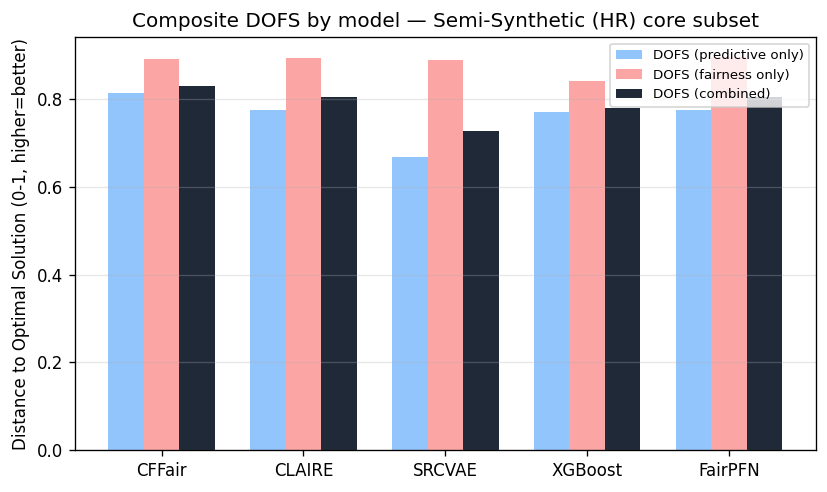

,DOFS,DOFS_predictive,DOFS_fairness
model_name,,,
CFFair,0.829,0.814,0.890
CLAIRE,0.803,0.775,0.893
SRCVAE,0.726,0.667,0.888
XGBoost,0.780,0.769,0.841
FairPFN,0.805,0.775,0.896


In [19]:
means_semi = semi_core.groupby('model_name')[['DOFS', 'DOFS_predictive', 'DOFS_fairness']].mean().reindex(MODELS)
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(MODELS)); w = 0.25
ax.bar(x - w, means_semi['DOFS_predictive'], width=w, label='DOFS (predictive only)', color='#93c5fd')
ax.bar(x, means_semi['DOFS_fairness'], width=w, label='DOFS (fairness only)', color='#fca5a5')
ax.bar(x + w, means_semi['DOFS'], width=w, label='DOFS (combined)', color='#1f2937')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel('Distance to Optimal Solution (0-1, higher=better)')
ax.set_title('Composite DOFS by model — Semi-Synthetic (HR) core subset')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_dofs_bar.png'))
plt.show()
display(means_semi.round(3))

## 7. Cross-model ranking & rank correlation

Ranks each model on every individual metric plus combined DOFS (1 = best), then checks whether DOFS is just tracking one metric or genuinely aggregating (Spearman rank correlation).

In [20]:
metrics = ['F1_Score', 'ROC_AUC', 'Recall', 'Statistical_Parity_Diff_(ATE)', 'Equal_Opportunity_Diff', 'DIR_dist', 'DOFS']
ascending_map = {'F1_Score': False, 'ROC_AUC': False, 'Recall': False,
                 'Statistical_Parity_Diff_(ATE)': True, 'Equal_Opportunity_Diff': True, 'DIR_dist': True, 'DOFS': False}

def rank_table(df, label):
    means = df.groupby('model_name')[metrics].mean().reindex(MODELS)
    ranks = pd.DataFrame(index=means.index)
    for m in metrics:
        ranks[m] = means[m].rank(ascending=ascending_map[m]).astype(int)
    print(f'=== {label}: mean values ===')
    display(means.round(4))
    print(f'=== {label}: rank table (1=best) ===')
    display(ranks)
    print(f'=== {label}: Spearman corr of DOFS rank vs each metric rank ===')
    for m in metrics[:-1]:
        rho, p = spearmanr(ranks['DOFS'], ranks[m])
        print(f'  {m}: rho={rho:.3f}')
    print()
    means.to_csv(os.path.join(TABLES_DIR, f'{label.replace(" ", "_").lower()}_means.csv'))
    ranks.to_csv(os.path.join(TABLES_DIR, f'{label.replace(" ", "_").lower()}_ranks.csv'))
    return means, ranks

syn_means, syn_ranks = rank_table(syn_core, 'SYN core')
semi_means, semi_ranks = rank_table(semi_core, 'SEMI core')

=== SYN core: mean values ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,0.9026,0.9564,0.9003,0.3416,0.1122,0.4788,0.7850
CLAIRE,0.8541,0.9185,0.8394,0.3314,0.1496,0.4699,0.7612
SRCVAE,0.5931,0.7040,0.5845,0.1633,0.1551,0.3388,0.6760
XGBoost,0.7525,0.8146,0.7527,0.3387,0.2745,0.4447,0.6952
FairPFN,0.6912,0.7484,0.7320,0.0389,0.0670,0.0663,0.7683


=== SYN core: rank table (1=best) ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,1,1,1,5,2,5,1
CLAIRE,2,2,2,3,3,4,3
SRCVAE,5,5,5,2,4,2,5
XGBoost,3,3,3,4,5,3,4
FairPFN,4,4,4,1,1,1,2


=== SYN core: Spearman corr of DOFS rank vs each metric rank ===
  F1_Score: rho=0.700
  ROC_AUC: rho=0.700
  Recall: rho=0.700
  Statistical_Parity_Diff_(ATE): rho=-0.300
  Equal_Opportunity_Diff: rho=0.800
  DIR_dist: rho=-0.400

=== SEMI core: mean values ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,0.8250,0.8082,0.8393,0.0337,0.0863,0.1808,0.8291
CLAIRE,0.7681,0.7736,0.7955,0.0265,0.0558,0.2013,0.8035
SRCVAE,0.6589,0.5676,0.7060,0.0084,0.0119,0.2549,0.7260
XGBoost,0.7996,0.7174,0.8110,0.0814,0.1184,0.2612,0.7797
FairPFN,0.7686,0.7732,0.7945,0.0223,0.0695,0.1820,0.8049


=== SEMI core: rank table (1=best) ===


,F1_Score,ROC_AUC,Recall,Statistical_Parity_Diff_(ATE),Equal_Opportunity_Diff,DIR_dist,DOFS
model_name,,,,,,,
CFFair,1,1,1,4,4,1,1
CLAIRE,4,2,3,3,2,3,3
SRCVAE,5,5,5,1,1,4,5
XGBoost,2,4,2,5,5,5,4
FairPFN,3,3,4,2,3,2,2


=== SEMI core: Spearman corr of DOFS rank vs each metric rank ===
  F1_Score: rho=0.700
  ROC_AUC: rho=0.900
  Recall: rho=0.600
  Statistical_Parity_Diff_(ATE): rho=-0.300
  Equal_Opportunity_Diff: rho=-0.400
  DIR_dist: rho=0.900



### 7.1 Ranking heatmap

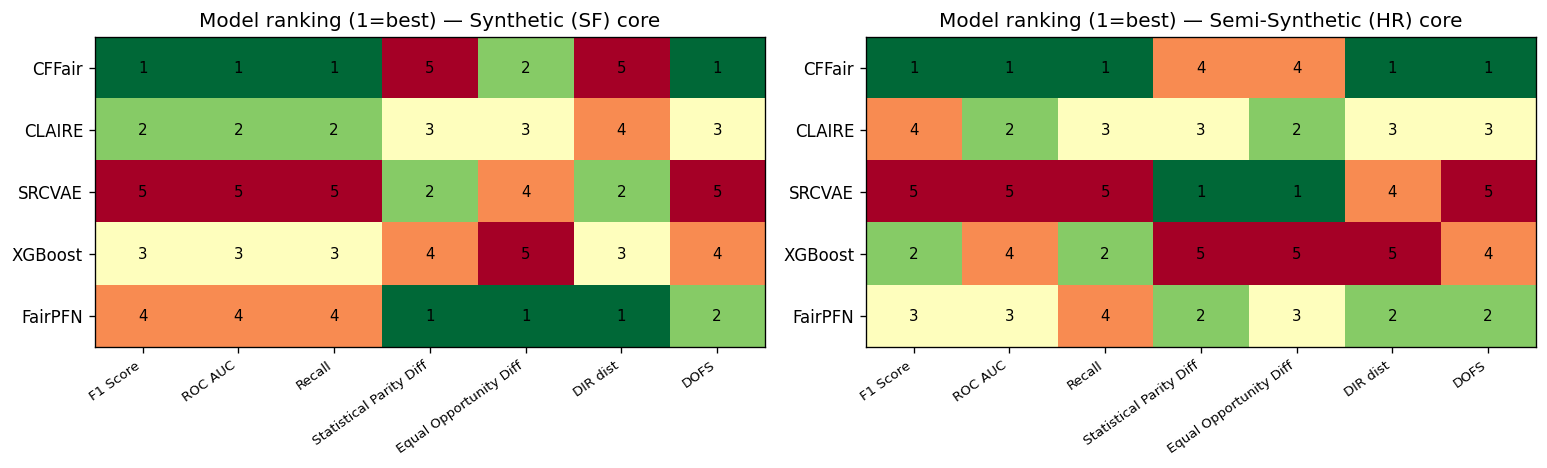

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ranks, title in zip(axes, [syn_ranks, semi_ranks], ['Synthetic (SF) core', 'Semi-Synthetic (HR) core']):
    im = ax.imshow(ranks, cmap='RdYlGn_r', vmin=1, vmax=5, aspect='auto')
    ax.set_yticks(range(len(ranks.index))); ax.set_yticklabels(ranks.index)
    ax.set_xticks(range(len(ranks.columns))); ax.set_xticklabels(
        [c.replace('_(ATE)', '').replace('_', ' ') for c in ranks.columns], rotation=35, ha='right', fontsize=8)
    for i in range(ranks.shape[0]):
        for j in range(ranks.shape[1]):
            ax.text(j, i, ranks.iloc[i, j], ha='center', va='center', fontsize=9)
    ax.set_title(f'Model ranking (1=best) — {title}')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'rank_tables.png'))
plt.show()

### 7.2 Final cross-regime DOFS comparison

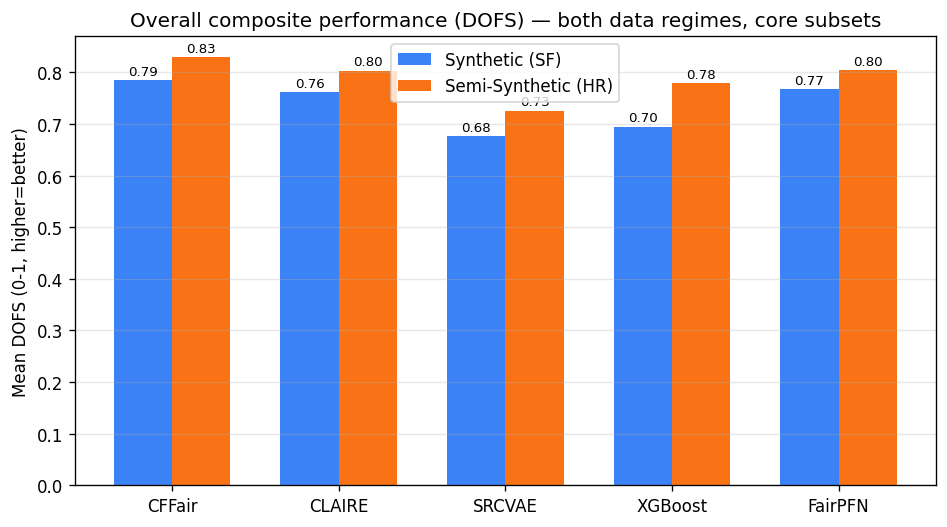

In [22]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(MODELS)); w = 0.35
ax.bar(x - w/2, syn_means['DOFS'], width=w, label='Synthetic (SF)', color='#3b82f6')
ax.bar(x + w/2, semi_means['DOFS'], width=w, label='Semi-Synthetic (HR)', color='#f97316')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel('Mean DOFS (0-1, higher=better)')
ax.set_title('Overall composite performance (DOFS) — both data regimes, core subsets')
ax.legend(); ax.grid(alpha=0.3, axis='y')
for i, v in enumerate(syn_means['DOFS']): ax.text(i - w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
for i, v in enumerate(semi_means['DOFS']): ax.text(i + w/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'dofs_final_comparison.png'))
plt.show()

## 8. Sensitivity analysis (EBM-style)

InterpretML's Explainable Boosting Machine (used in the source paper) needs network access to install; this uses `HistGradientBoostingRegressor` + permutation importance as a substitute — same "what drives the outcome" reading. If you have `interpret` installed locally, swap in `ExplainableBoostingRegressor` for a closer match to the paper, including native pairwise-interaction scores.

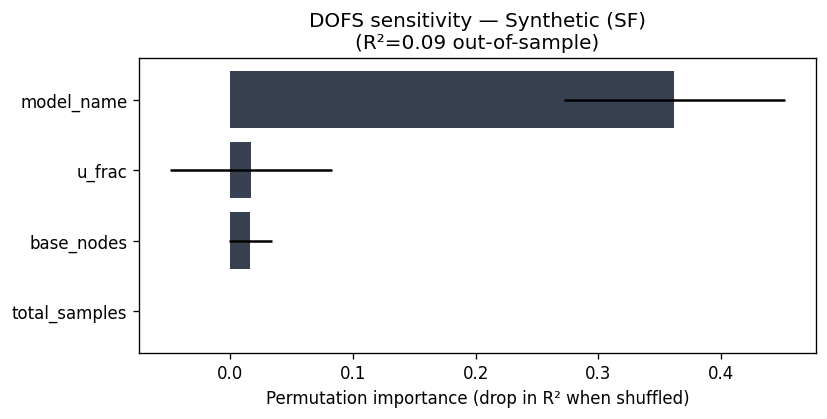

SF importance: {'model_name': 0.3619, 'base_nodes': 0.0164, 'u_frac': 0.0168, 'total_samples': 0.0}  R2: 0.086


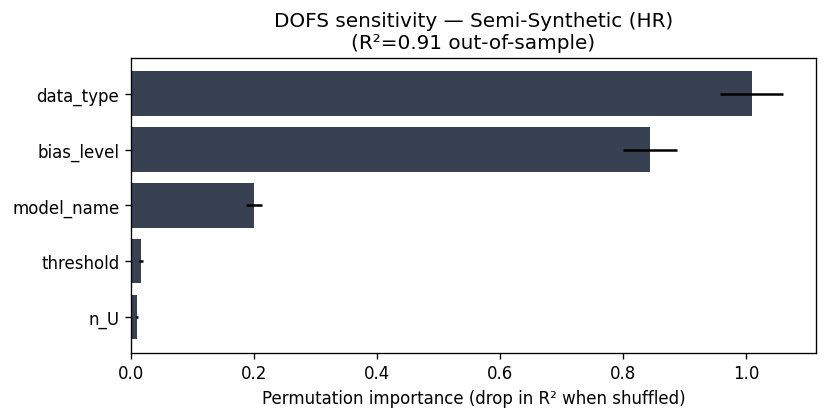

HR importance: {'model_name': 0.2005, 'bias_level': 0.8438, 'data_type': 1.0088, 'threshold': 0.0162, 'n_U': 0.0102}  R2: 0.907


In [23]:
def run_importance(df, features, target, cat_features, title, fname):
    d = df[features + [target]].dropna().copy()
    for c in cat_features:
        d[c] = d[c].astype('category').cat.codes
    X = d[features]; y = d[target]
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    model = HistGradientBoostingRegressor(random_state=42, max_depth=4)
    model.fit(Xtr, ytr)
    r2 = model.score(Xte, yte)
    imp = permutation_importance(model, Xte, yte, n_repeats=20, random_state=42)
    order = np.argsort(imp.importances_mean)[::-1]
    fig, ax = plt.subplots(figsize=(7, 3.6))
    ax.barh([features[i] for i in order][::-1], imp.importances_mean[order][::-1],
            xerr=imp.importances_std[order][::-1], color='#374151')
    ax.set_xlabel('Permutation importance (drop in R² when shuffled)')
    ax.set_title(f'{title}\n(R²={r2:.2f} out-of-sample)', fontsize=12)
    plt.tight_layout(); plt.savefig(fname)
    plt.show()
    return dict(zip(features, imp.importances_mean)), r2

syn_features = ['model_name', 'base_nodes', 'u_frac', 'total_samples']
imp_syn, r2_syn = run_importance(syn_all, syn_features, 'DOFS', ['model_name'],
                                  'DOFS sensitivity — Synthetic (SF)',
                                  os.path.join(CHARTS_DIR, 'syn_importance.png'))
print('SF importance:', {k: round(v, 4) for k, v in imp_syn.items()}, ' R2:', round(r2_syn, 3))

semi_features = ['model_name', 'bias_level', 'data_type', 'threshold', 'n_U']
imp_semi, r2_semi = run_importance(semi_all, semi_features, 'DOFS', ['model_name', 'bias_level', 'data_type'],
                                    'DOFS sensitivity — Semi-Synthetic (HR)',
                                    os.path.join(CHARTS_DIR, 'semi_importance.png'))
print('HR importance:', {k: round(v, 4) for k, v in imp_semi.items()}, ' R2:', round(r2_semi, 3))

### 8.1 Interaction heatmaps (grouped-mean proxy for pairwise EBM interactions)

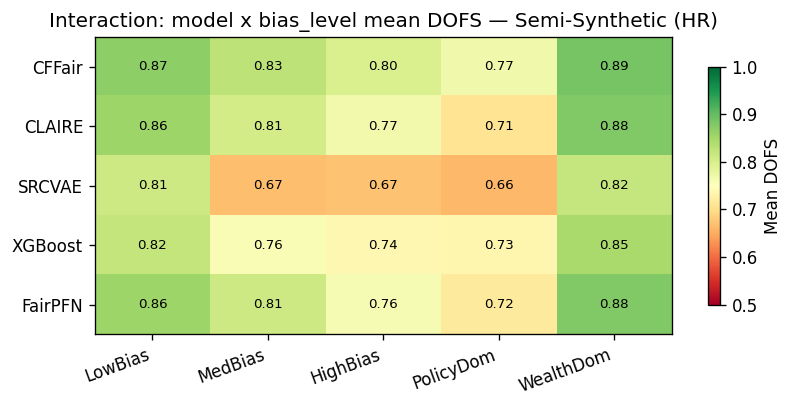

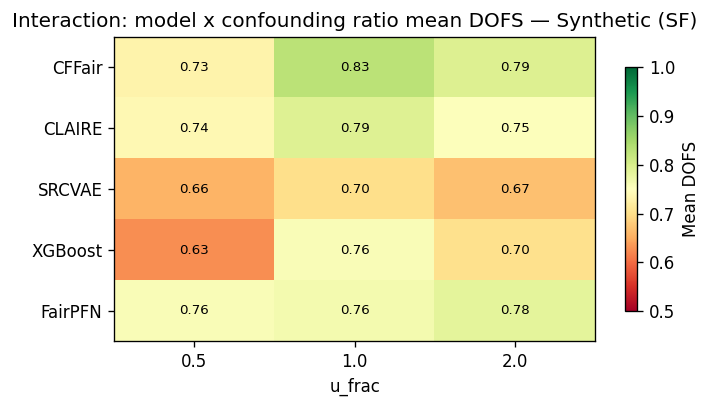

In [24]:
core = semi_all[(semi_all.data_type.isin(['BIASED_ALL', 'FAIR_ALL'])) & (semi_all.n_U == 4)]
piv = core.groupby(['model_name', 'bias_level'])['DOFS'].mean().unstack().reindex(MODELS)[BIAS_ORDER]
fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(piv, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=20, ha='right')
for i in range(piv.shape[0]):
    for j in range(piv.shape[1]):
        ax.text(j, i, f'{piv.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Interaction: model x bias_level mean DOFS — Semi-Synthetic (HR)')
plt.colorbar(im, shrink=0.8, label='Mean DOFS')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'semi_interaction_model_bias.png'))
plt.show()

core2 = syn_all[syn_all.u_frac.isin([0.5, 1.0, 2.0])]
piv2 = core2.groupby(['model_name', 'u_frac'])['DOFS'].mean().unstack().reindex(MODELS)
fig, ax = plt.subplots(figsize=(6, 3.5))
im = ax.imshow(piv2, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax.set_yticks(range(len(piv2.index))); ax.set_yticklabels(piv2.index)
ax.set_xticks(range(len(piv2.columns))); ax.set_xticklabels(piv2.columns)
for i in range(piv2.shape[0]):
    for j in range(piv2.shape[1]):
        ax.text(j, i, f'{piv2.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_xlabel('u_frac'); ax.set_title('Interaction: model x confounding ratio mean DOFS — Synthetic (SF)')
plt.colorbar(im, shrink=0.8, label='Mean DOFS')
plt.tight_layout(); plt.savefig(os.path.join(CHARTS_DIR, 'syn_interaction_model_ufrac.png'))
plt.show()

## 9. Done

**To refresh with new results:** overwrite the 10 CSVs (same filenames) and re-run all cells — every number, chart, and table above will update automatically. No hand-typed values anywhere in this notebook.